In [1]:
import scanpy as sc
import os
import scanpy as sc
import pandas as pd
import numpy as np
os.getcwd()

'/home/lixiangyu/zr/Annotate/ANNOTATE_new/10_downstream/cell_type_rename'

# Human

In [2]:
indir="/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_allhuman/"
adata_human = sc.read_h5ad(indir+"scPoli_concat_level3_marker_all_metadata.h5ad")
adata_human

AnnData object with n_obs × n_vars = 1004247 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3', 'Plaque_type'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [3]:
adata_human.var_names = adata_human.var['original_gene_names'].values

adata_human.var_names

Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A3GALT2',
       'A4GALT', 'A4GNT', 'AAAS',
       ...
       'ZW10', 'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B',
       'ZYX', 'ZZEF1'],
      dtype='object', length=28868)

In [4]:
adata_human.var

,original_gene_names,ensembl_id
A1BG,A1BG,ENSG00000121410
A1BG-AS1,A1BG-AS1,ENSG00000268895
A1CF,A1CF,ENSG00000148584
A2M,A2M,ENSG00000175899
A2M-AS1,A2M-AS1,ENSG00000245105
...,...,...
ZXDC,ZXDC,ENSG00000070476
ZYG11A,ZYG11A,ENSG00000203995
ZYG11B,ZYG11B,ENSG00000162378
ZYX,ZYX,ENSG00000159840


## CD8 T cell

### PDCD1-high CD8 T / LAYN+ CD8 T / exhausted CD8 T

In [7]:
level1_marker = {
    'Exhausted CD8 T cell': ['PDCD1', 'CTLA4', 'LAG3', 'TOX', 'LAYN'],   
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_human.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_human.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_human.var_names))

Exhausted CD8 T cell 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

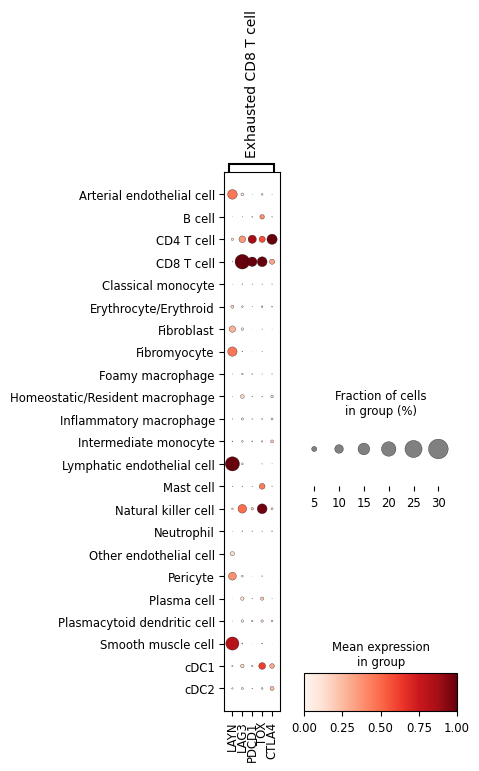

In [9]:
dp = sc.pl.dotplot(
    adata_human,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (3,7),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

### TOX+ CD8 T

In [10]:
level1_marker = {
    'TOX+ CD8 T': ['TOX', 'PDCD1', 'LAG3'],   
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_human.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_human.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_human.var_names))

TOX+ CD8 T 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

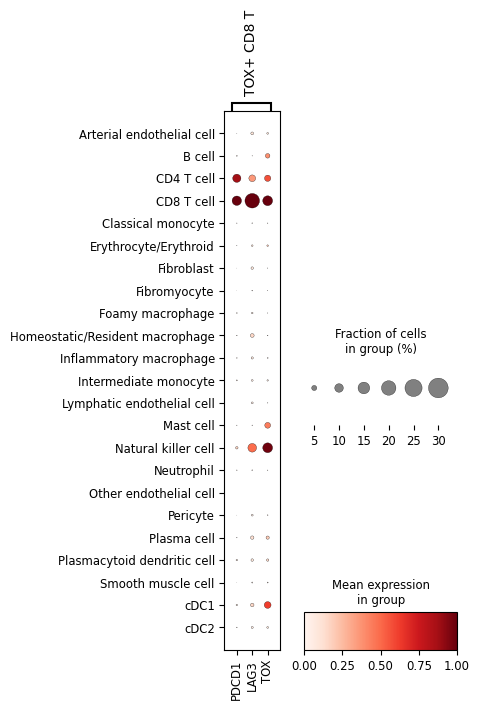

In [12]:
dp = sc.pl.dotplot(
    adata_human,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (3,7),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

## Foam macrophage-level2！

### TREM2+ macrophage

In [29]:
level1_marker = {
    'TREM2+ macrophage': ['TREM2', 'APOE', 'APOC1', 'CD9', 'GPNMB', 'FABP5'],
    'Triglyceride/Vesicle-Trafficking-biased Foamy macrophage': ['TREM2', 'APOE', 'APOC1', 'CD9', 'GPNMB', 'FABP5', 'FABP4', 'CD63', 'PLTP', 'LIPA', 'LPL', 'SPP1'],
    'Cholesteryl-Ester-rich Foamy macrophage': ['PLIN2', 'PLIN3', 'CD36', 'SOAT1', 'FABP5', 'APOC2', 'LPL'],

    
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_human.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_human.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_human.var_names))

TREM2+ macrophage 1.0
not included:  set()
Triglyceride/Vesicle-Trafficking-biased Foamy macrophage 1.0
not included:  set()
Cholesteryl-Ester-rich Foamy macrophage 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

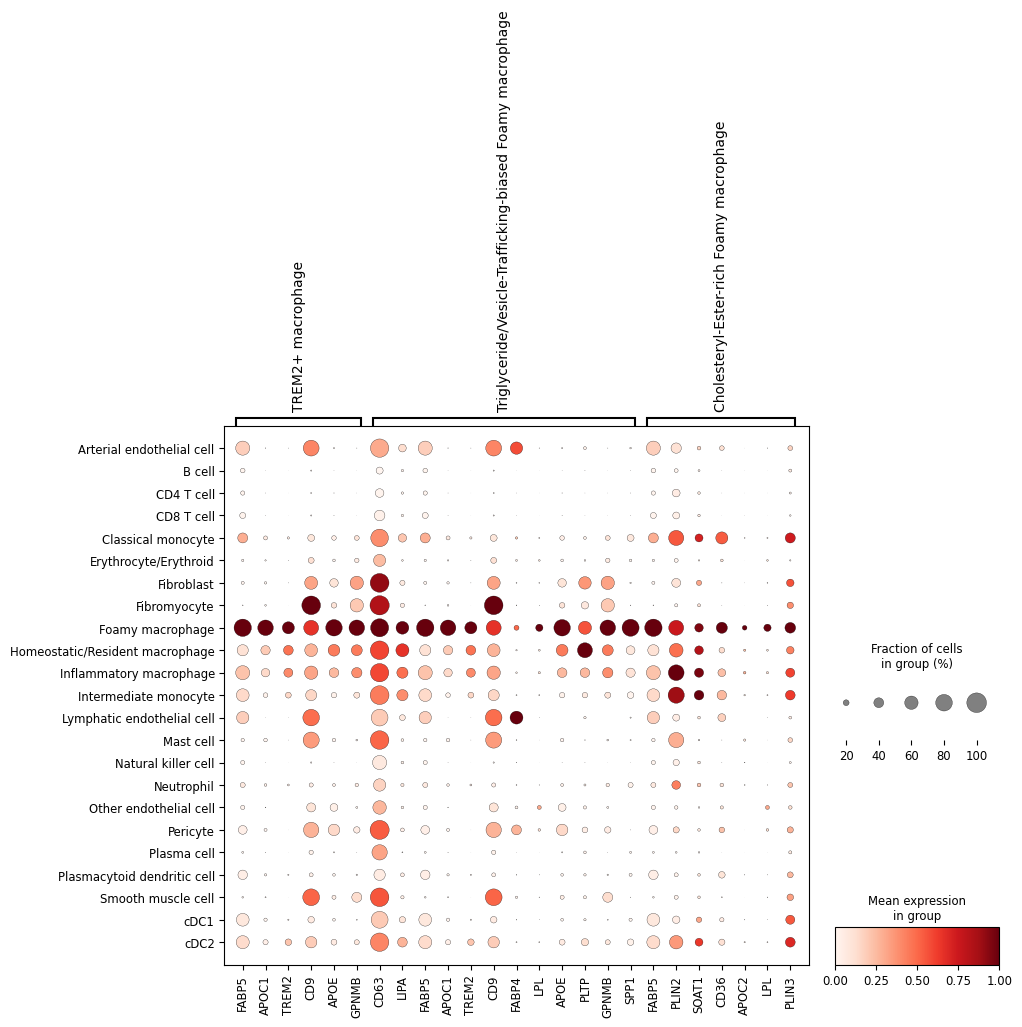

In [30]:
dp = sc.pl.dotplot(
    adata_human,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (10,7),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

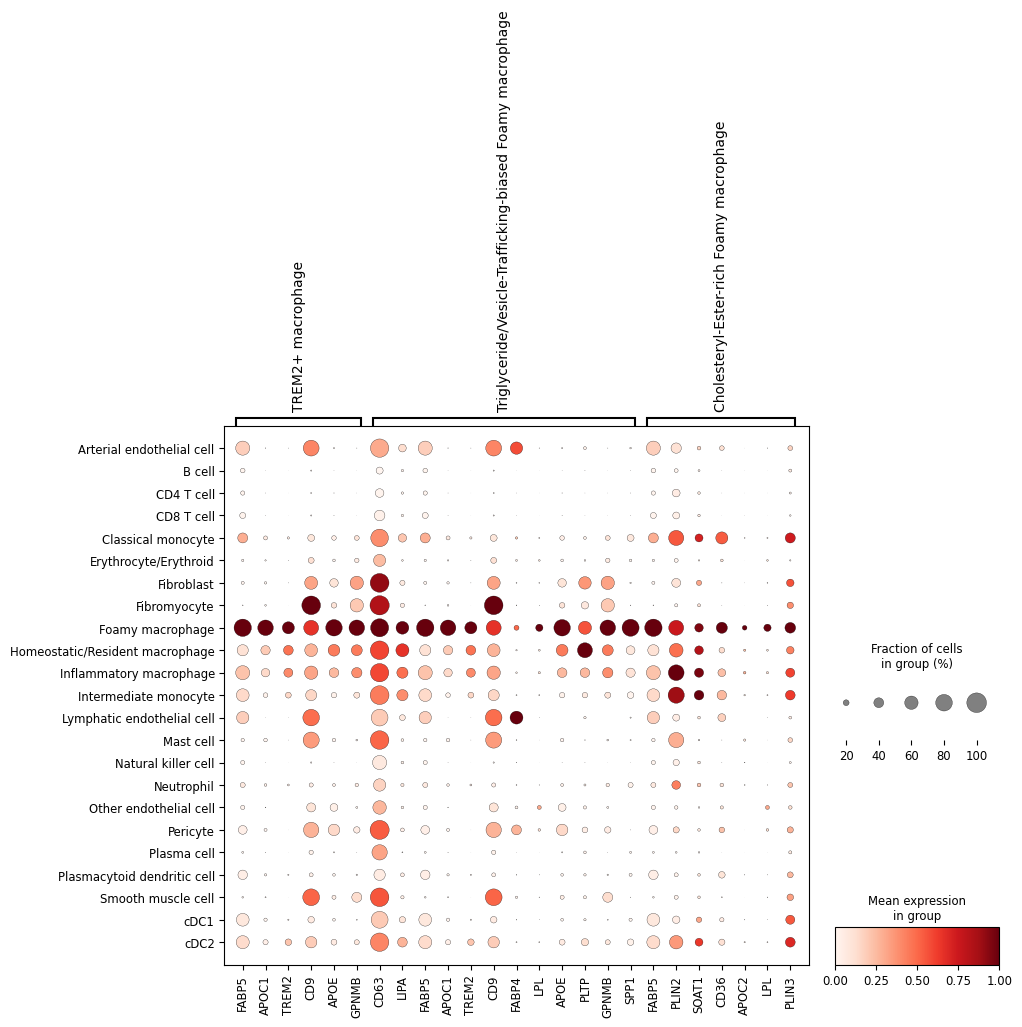

In [31]:
dp = sc.pl.dotplot(
    adata_human,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (10,7),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

### FABP4+ macrophages

In [8]:
level1_marker = {
    'FABP4+ macrophages': ['FABP4', 'FABP5', 'CD36', 'APOE', 'LPL']    
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_human.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_human.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_human.var_names))

FABP4+ macrophages 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

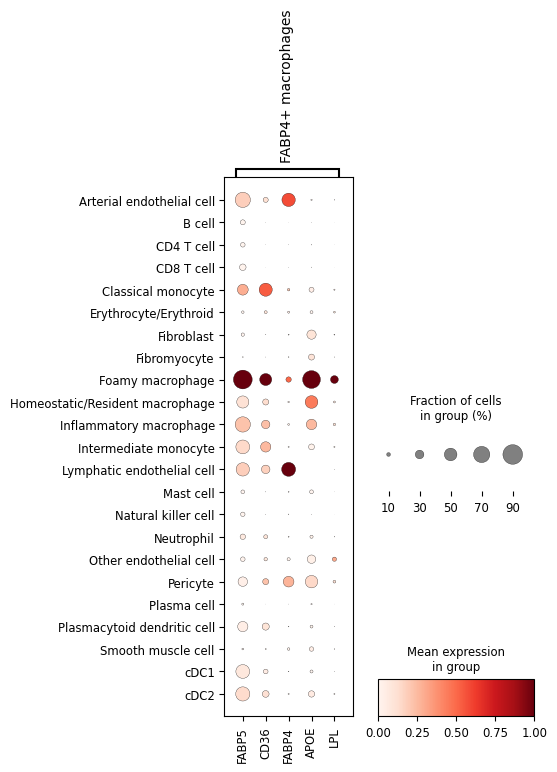

In [9]:
dp = sc.pl.dotplot(
    adata_human,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (4,7),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

## inflammatory macrophage-Pro-level3

### SPP1+ macrophages

In [ ]:
level1_marker = {
    'SPP1+ macrophage': ['SPP1', 'ITGAX', 'TNF', 'IL1B'],
    # "Pro-inflammatory macrophage": ['SPP1', 'CD9', 'MMP12', 'TREM2', 'TNF', 'IL1B', 'NFKBIA', 'NFKBIZ', 'ITGAX']

    
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_human.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_human.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_human.var_names))

SPP1+ macrophage 1.0
not included:  set()
Pro-inflammatory macrophage 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

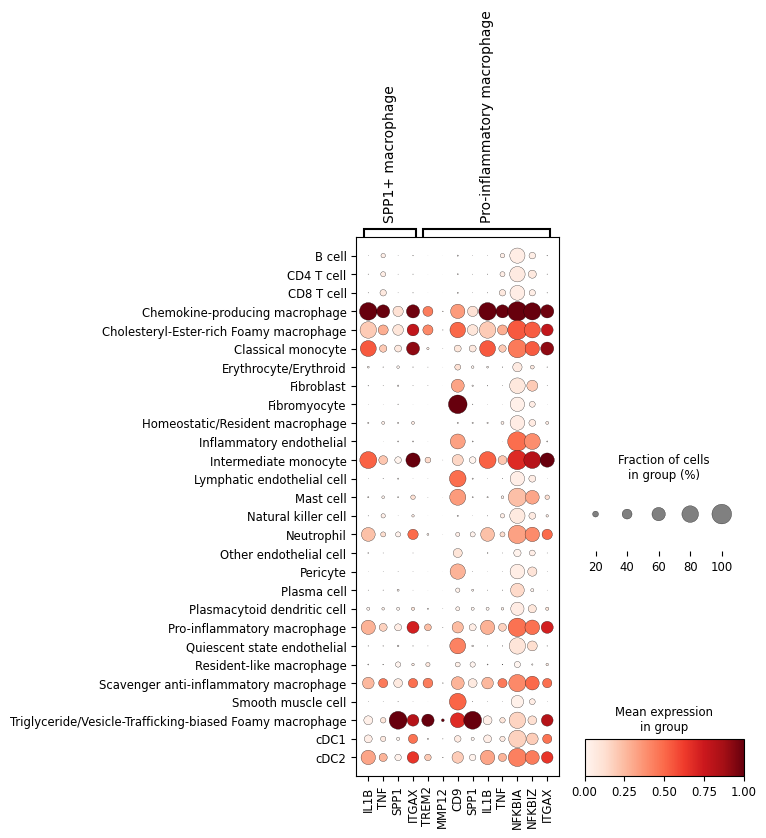

In [11]:
dp = sc.pl.dotplot(
    adata_human,
    groupby="cell_type_level3",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (5,7),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

## Homeostatic/Resident macrophage！

### FOLR2+ macrophages

In [23]:
level1_marker = {
    'FOLR2+ macrophages': ['FOLR2', 'C1QA','C1QB','C1QC', 'SEPP1', 'CD206','MRC1', 'APOE']
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_human.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_human.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_human.var_names))

FOLR2+ macrophages 0.75
not included:  {'CD206', 'SEPP1'}


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

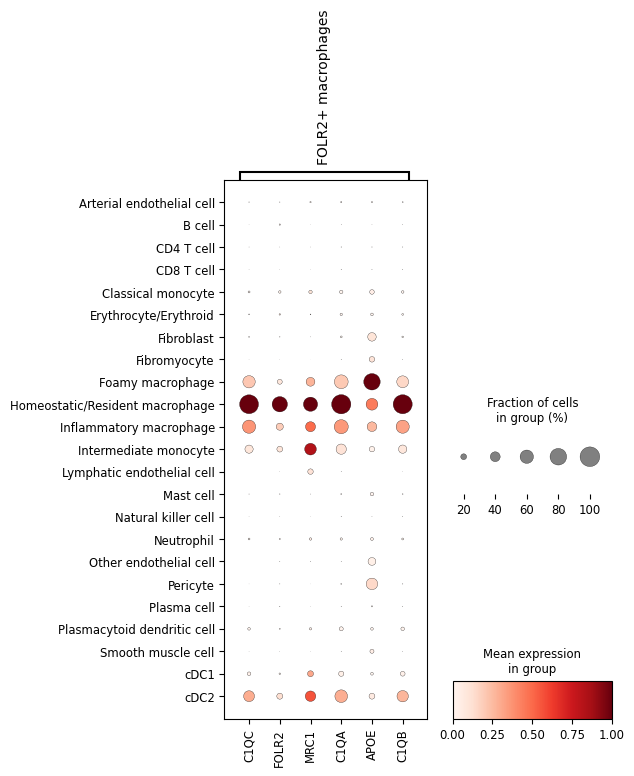

In [24]:
dp = sc.pl.dotplot(
    adata_human,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (5,7),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

### LYVE1+ macrophages 

In [25]:
level1_marker = {
    'LYVE1+ macrophage': ['LYVE1', 'MRC1','CD206', 'F13A1', 'SEPP1', 'C1QA','C1QB','C1QC'],
     "Resident-like macrophage": ['LYVE1', 'FOLR2',  'F13A1', 'STAB1', 'SEPP1'], 
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_human.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_human.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_human.var_names))

LYVE1+ macrophage 0.75
not included:  {'CD206', 'SEPP1'}
Resident-like macrophage 0.8
not included:  {'SEPP1'}


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

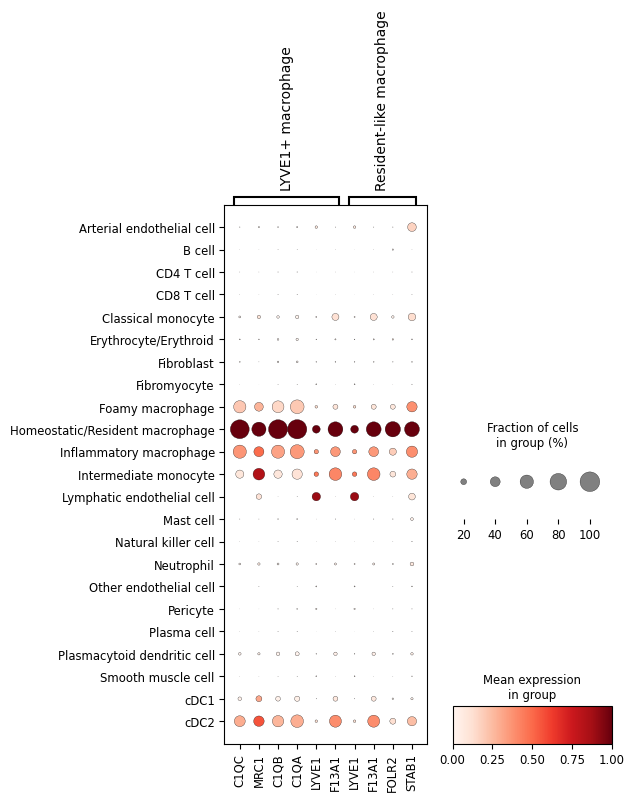

In [26]:
dp = sc.pl.dotplot(
    adata_human,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (5,7),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

## Endothelial cell

### SELE+ EC / VCAM1+ EC / ICAM1+ EC / activated endothelial cell

In [22]:
level1_marker = {
    'SELE+ EC / VCAM1+ EC / ICAM1+ EC / activated endothelial cell ': ['SELE', 'VCAM1', 'ICAM1', 'IL6', 'CCL2', 'CXCL8', 'NFKBIA'],
    #  "Arterial endothelial cell": ['GJ4', 'GJ5', "GATA2", "MECOM", "GJA4", "GJA5"],
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_human.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_human.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_human.var_names))

SELE+ EC / VCAM1+ EC / ICAM1+ EC / activated endothelial cell  1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

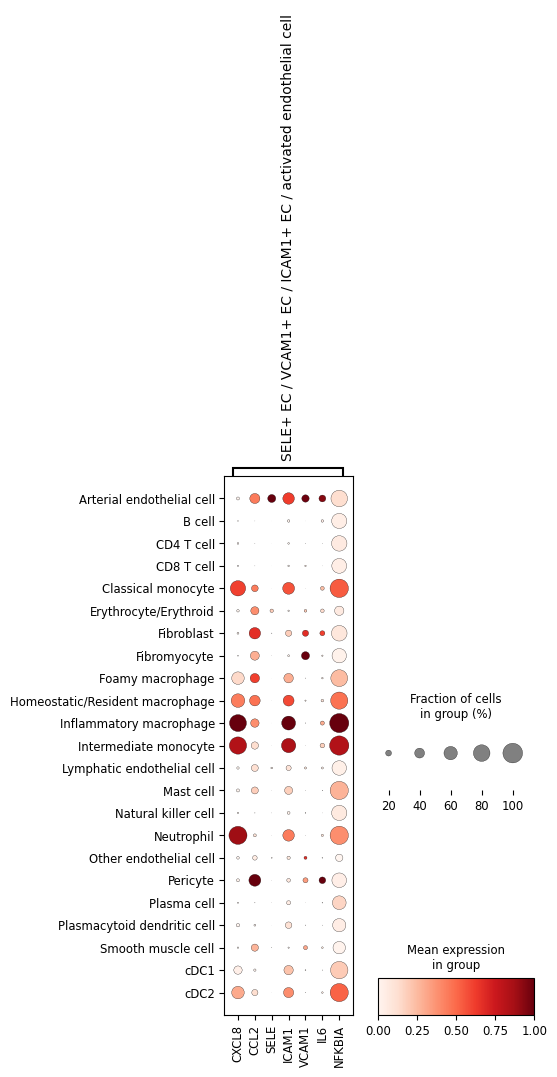

In [23]:
dp = sc.pl.dotplot(
    adata_human,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (4,7),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

## EndoMT

### SULF1+ arterial EC 

In [33]:
level1_marker = {
    'SULF1+ arterial EC': ['SULF1', 'COL1A1','COL1A2', 'TAGLN', 'ACTA2', 'FN1'],
    # "EndoMT":['COL1A1', 'COL1A2', 'TAGLN', 'ACTA2', 'FN1', 'SNAI1', 'SNAI2'],
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_human.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_human.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_human.var_names))

SULF1+ arterial EC 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

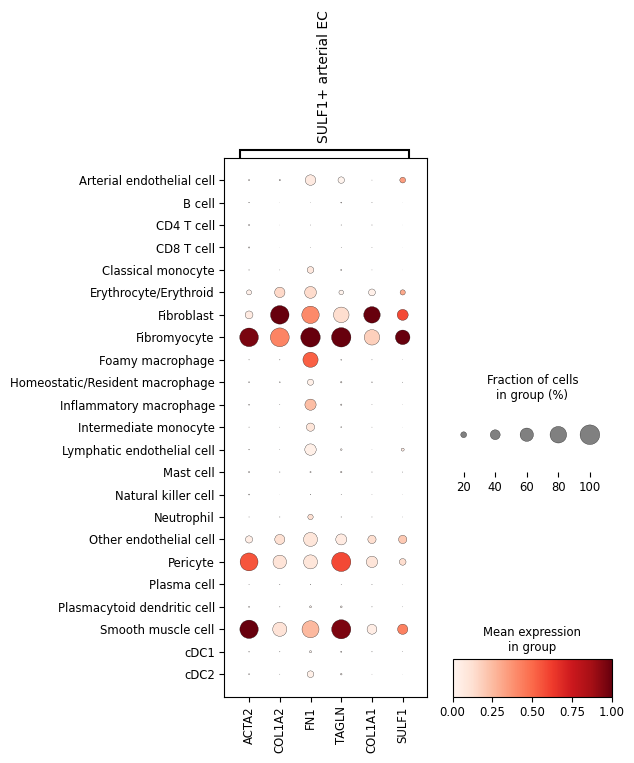

In [ ]:
dp = sc.pl.dotplot(
    adata_human,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (5,7),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

# Mouse 

In [24]:
indir="/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_mouse/"
adata_mouse = sc.read_h5ad(indir+"scPoli_concat_level3_marker_allmouse.h5ad")
adata_mouse

AnnData object with n_obs × n_vars = 564966 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3'
    var: 'original_gene_names'
    uns: 'cell_type_level1_corrected_colors', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18

In [25]:
adata_mouse.var

,original_gene_names
ENSMUSG00000109644,0610005C13Rik
ENSMUSG00000108652,0610006L08Rik
ENSMUSG00000086714,0610009E02Rik
ENSMUSG00000043644,0610009L18Rik
ENSMUSG00000020831,0610010K14Rik
...,...
ENSMUSG00000119837,n-R5s71
ENSMUSG00000119155,n-R5s86
ENSMUSG00000065107,n-R5s88
ENSMUSG00000119822,n-R5s92


In [26]:
adata_mouse.var['ensemble_id'] = adata_mouse.var_names
adata_mouse.var_names = adata_mouse.var['original_gene_names'].values
adata_mouse.var

,original_gene_names,ensemble_id
0610005C13Rik,0610005C13Rik,ENSMUSG00000109644
0610006L08Rik,0610006L08Rik,ENSMUSG00000108652
0610009E02Rik,0610009E02Rik,ENSMUSG00000086714
0610009L18Rik,0610009L18Rik,ENSMUSG00000043644
0610010K14Rik,0610010K14Rik,ENSMUSG00000020831
...,...,...
n-R5s71,n-R5s71,ENSMUSG00000119837
n-R5s86,n-R5s86,ENSMUSG00000119155
n-R5s88,n-R5s88,ENSMUSG00000065107
n-R5s92,n-R5s92,ENSMUSG00000119822


## Inflammatory macrophage

In [27]:
adata_infla_mac_m = adata_mouse[adata_mouse.obs['cell_type_level1_corrected'] == 'Macrophage']
adata_infla_mac_m

View of AnnData object with n_obs × n_vars = 113145 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3'
    var: 'original_gene_names', 'ensemble_id'
    uns: 'cell_type_level1_corrected_colors', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP'

### Spp1+ macrophage

In [31]:
level1_marker = {
    'Spp1+ macrophage': ['Spp1', 'Cd9', 'Mmp12',  'Tnf']###'Itgax', 'Il1b',
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_mouse.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_mouse.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_mouse.var_names))

Spp1+ macrophage 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

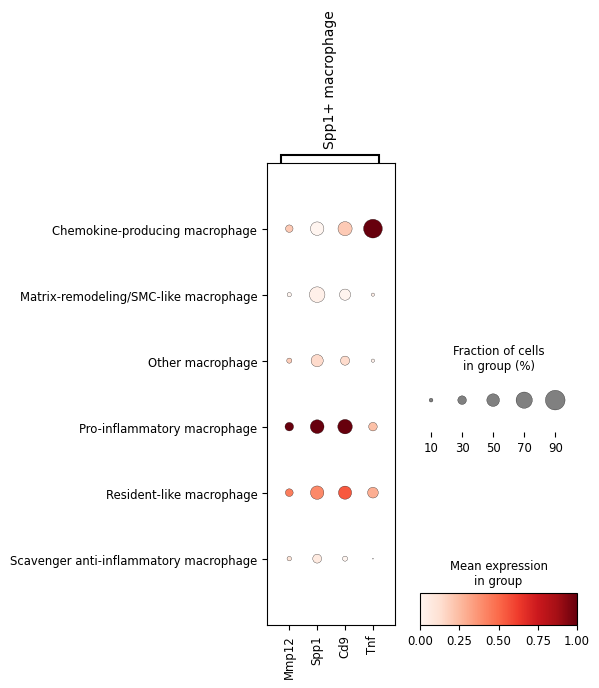

In [35]:
dp = sc.pl.dotplot(
    adata_infla_mac_m,
    groupby="cell_type_level3",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (4,6),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

### Chemokine^hi macrophage

In [60]:
level1_marker = {
    'Chemokine^hi macrophage': ['Ccl4', 'Cxcl2', 'Ccl3', 'Ccl2', 'Tnf', 'Cxcl1', 'Cxcl10', 'Ccl5']###'Itgax', 'Il1b',
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_mouse.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_mouse.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_mouse.var_names))

Chemokine^hi macrophage 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

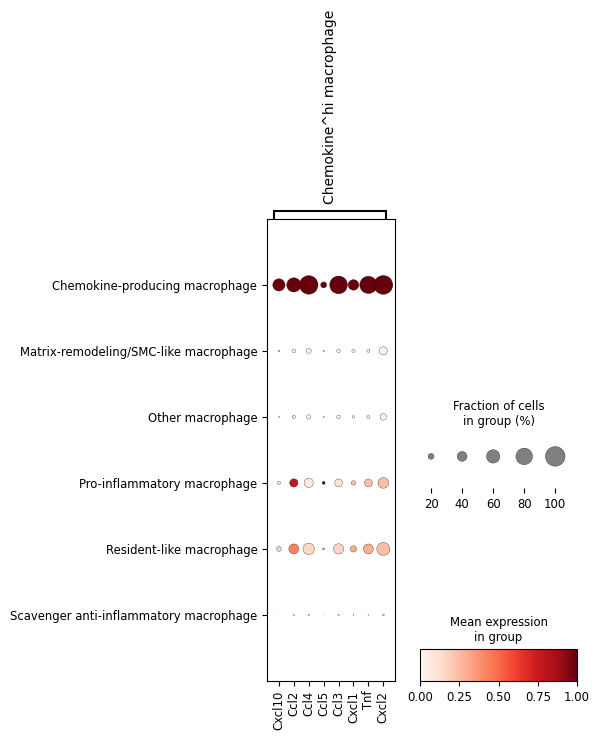

In [61]:
dp = sc.pl.dotplot(
    adata_infla_mac_m,
    groupby="cell_type_level3",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (4,6),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

## Classical monocyte 

In [36]:
adata_cla_mono_m = adata_mouse[adata_mouse.obs['cell_type_level1_corrected'] == 'Monocyte']
adata_cla_mono_m

View of AnnData object with n_obs × n_vars = 12280 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3'
    var: 'original_gene_names', 'ensemble_id'
    uns: 'cell_type_level1_corrected_colors', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP',

### Ccr2+ monocyte

In [37]:
level1_marker = {
    'Ccr2+ monocyte': ['Ccr2', 'Ly6c2']
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_mouse.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_mouse.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_mouse.var_names))

Ccr2+ monocyte 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

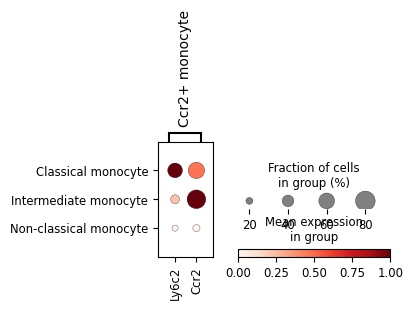

In [42]:
dp = sc.pl.dotplot(
    adata_cla_mono_m,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (3,1.5),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

## non-classical monocyte

### Ly6Clow / Cx3cr1hi / Nr4a1+ monocyte

In [43]:
level1_marker = {
    'Ly6Clow-Cx3cr1hi-Nr4a1+ monocyte': ['Cx3cr1', 'Nr4a1', 'Fcgr4', 'Itgal']
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_mouse.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_mouse.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_mouse.var_names))

Ly6Clow-Cx3cr1hi-Nr4a1+ monocyte 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

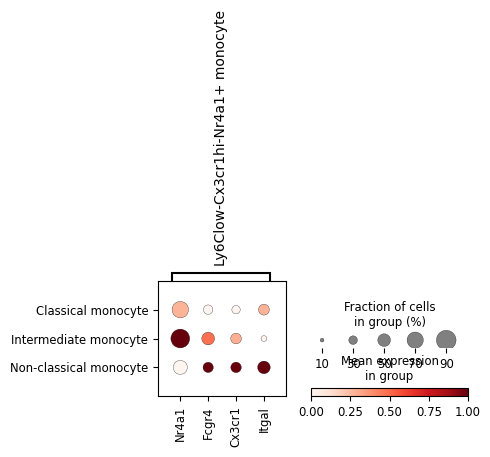

In [45]:
dp = sc.pl.dotplot(
    adata_cla_mono_m,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (4,1.5),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

## cDC1

In [46]:
adata_DC_m = adata_mouse[adata_mouse.obs['cell_type_level1_corrected'] == 'Dendritic cell']
adata_DC_m

View of AnnData object with n_obs × n_vars = 26476 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3'
    var: 'original_gene_names', 'ensemble_id'
    uns: 'cell_type_level1_corrected_colors', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP',

### Xcr1+ cDC1

In [47]:
level1_marker = {
    'Xcr1+ cDC1': ['Xcr1', 'Clec9a', 'Batf3', 'Irf8', 'Wdfy4']
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_mouse.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_mouse.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_mouse.var_names))

Xcr1+ cDC1 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

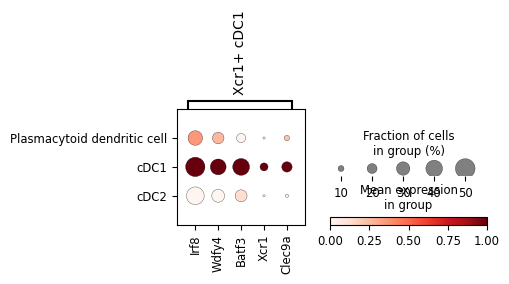

In [50]:
dp = sc.pl.dotplot(
    adata_DC_m,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (4,1.5),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

## SMC

In [51]:
adata_smc_m = adata_mouse[adata_mouse.obs['cell_type_level1_corrected'] == 'Smooth muscle cell']
adata_smc_m

View of AnnData object with n_obs × n_vars = 129258 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3'
    var: 'original_gene_names', 'ensemble_id'
    uns: 'cell_type_level1_corrected_colors', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP'

### Phenotypically modulated SMC / SEM-like SMC

In [52]:
level1_marker = {
    'Phenotypically modulated SMC / SEM-like SMC': ['Ly6a', 'Vcam1', 'Lgals3', 'S100a4', 'Fn1', 'Klf4']
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_mouse.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_mouse.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_mouse.var_names))

Phenotypically modulated SMC / SEM-like SMC 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

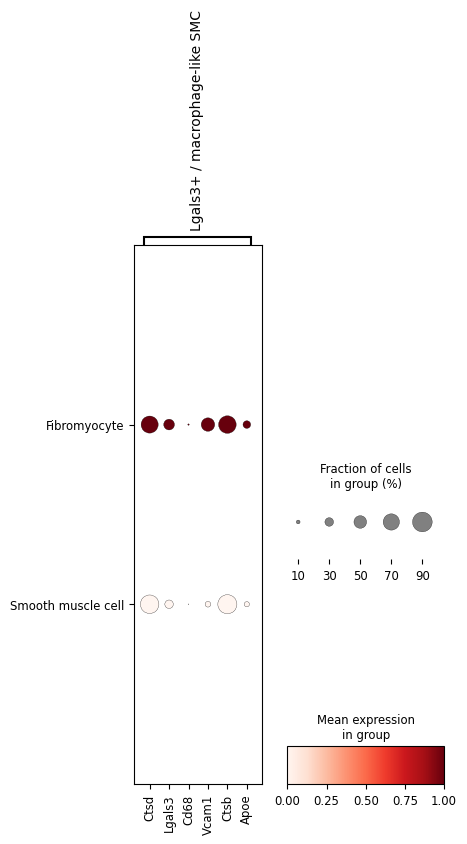

In [57]:
dp = sc.pl.dotplot(
    adata_smc_m,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (4,7),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")

### Lgals3+ / macrophage-like SMC

In [54]:
level1_marker = {
    'Lgals3+ / macrophage-like SMC': ['Lgals3', 'Cd68', 'Ctsb', 'Ctsd', 'Apoe', 'Vcam1']
}
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata_mouse.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata_mouse.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata_mouse.var_names))

Lgals3+ / macrophage-like SMC 1.0
not included:  set()


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

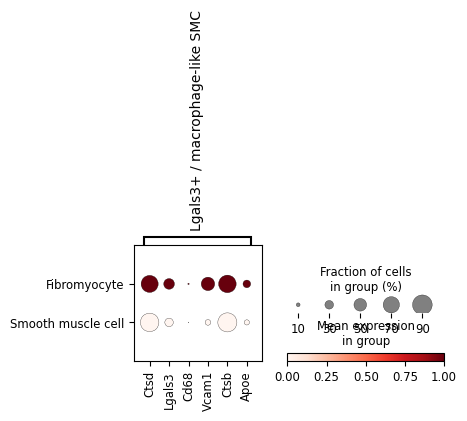

In [59]:
dp = sc.pl.dotplot(
    adata_smc_m,
    groupby="cell_type_level2",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    swap_axes = False,
    figsize = (4,1.5),
    return_fig = True
)

dp.legend(width=2.2)
dp.show()
# dp.savefig("figures/dotplot_mouse_corrected.pdf")